In [6]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [8]:
#reading a csv file 
df = pd.read_csv("mymoviedb.csv",lineterminator="\n")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [10]:
#to view dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [11]:
#exploring genres column
df["Genre"].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [15]:
#check for duplicate rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [17]:
#exploring summary statistics
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [18]:
# using the release date column and fetching the year only 
# as a part of data cleaning 

In [22]:
#casting column release date 
#converting release date into the datetime format
df["Release_Date"] = pd.to_datetime(df["Release_Date"])

print(df["Release_Date"].dtypes)

datetime64[ns]


In [23]:
#Fetching the year from datetime
df["Release_Date"] = df["Release_Date"].dt.year
df["Release_Date"].dtypes

dtype('int32')

In [24]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [25]:
# making a list of column to be droppped 
col = ["Overview",'Original_Language','Poster_Url']

In [26]:
#dropping the column not required 
df.drop(col,axis=1,inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [27]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [29]:
# we need to categorise the vote_average column into four major categories like popular,average,below average,non-popular .
def categorize_col(df,col,labels):
    #setting the edge to cut the column accordingly 
    edges = [df[col].describe()["min"],
            df[col].describe()["25%"],
            df[col].describe()["50%"],
            df[col].describe()["75%"],
            df[col].describe()["max"]]
    
    df[col] = pd.cut(df[col],edges,labels=labels,duplicates="drop")
    return df

#define labels for edges 
labels = ["popular","average","non_popular","below_average"]

#categorize column based on labels 
categorize_col(df,"Vote_Average",labels)

#confirming changes 
df["Vote_Average"].unique()

['below_average', 'average', 'non_popular', 'popular', NaN]
Categories (4, object): ['popular' < 'average' < 'non_popular' < 'below_average']

In [30]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,below_average,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,below_average,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,average,Thriller
3,2021,Encanto,2402.201,5076,below_average,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,non_popular,"Action, Adventure, Thriller, War"


In [31]:
df["Vote_Average"].value_counts()

Vote_Average
popular          2467
below_average    2450
non_popular      2412
average          2398
Name: count, dtype: int64

In [32]:
#dropping nan values
df.dropna(inplace=True)

#checking the nan values
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,below_average,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,below_average,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,average,Thriller
3,2021,Encanto,2402.201,5076,below_average,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,non_popular,"Action, Adventure, Thriller, War"


In [34]:
#split the strings into list
df["Genre"] = df["Genre"].str.split(",")

#explode the list
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Science Fiction
3,2022,The Batman,3827.658,1151,below_average,Crime
4,2022,The Batman,3827.658,1151,below_average,Mystery


In [36]:
#casting column into category
df["Genre"] = df['Genre'].astype('category')

#confirming changes
df['Genre'].dtype

CategoricalDtype(categories=[' Action', ' Adventure', ' Animation', ' Comedy', ' Crime',
                  ' Documentary', ' Drama', ' Family', ' Fantasy', ' History',
                  ' Horror', ' Music', ' Mystery', ' Romance',
                  ' Science Fiction', ' TV Movie', ' Thriller', ' War',
                  ' Western', 'Action', 'Adventure', 'Animation', 'Comedy',
                  'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
                  'History', 'Horror', 'Music', 'Mystery', 'Romance',
                  'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 750.3+ KB


In [38]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             38
dtype: int64

### Data Visualization

In [40]:
##setting up seaborn configuration
sns.set_style('whitegrid')

### what is the most frequent genre in the dataset?

In [41]:
#showing stats on a genre column
df['Genre'].describe()

count         25552
unique           38
top        Thriller
freq           1960
Name: Genre, dtype: object

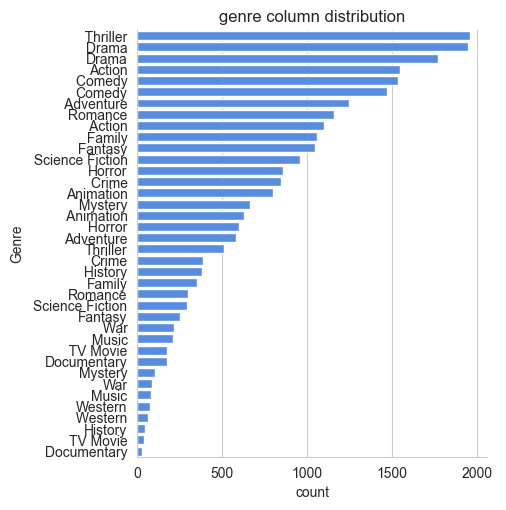

In [44]:
#visualizing genre column
sns.catplot(y='Genre',data=df,kind='count',
           order=df['Genre'].value_counts().index,
           color='#4287f5')

plt.title('genre column distribution')
plt.show()

### what genres has highest votes?

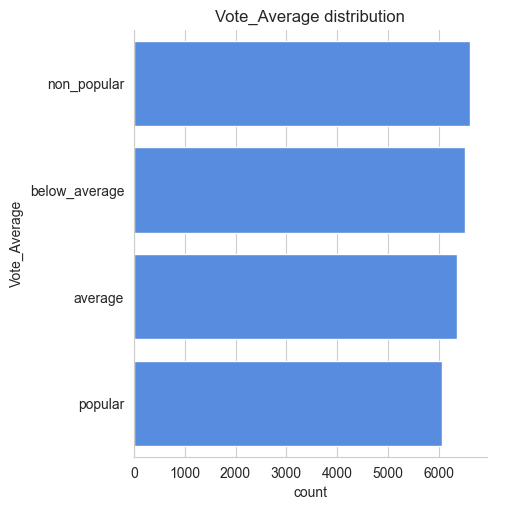

In [45]:
#visualizing vote_average column
sns.catplot(y='Vote_Average',data=df,kind='count',
           order=df['Vote_Average'].value_counts().index,
           color='#4287f5')

plt.title('Vote_Average distribution')
plt.show()

### what movie got the highest popularity? what's  its genre?

In [46]:
#checking max popularity in dataset 
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,below_average,Science Fiction


### what movie got the lowest popularity? what's its genre?

In [47]:
#checking min popularity in dataset 
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,non_popular,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,non_popular,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,non_popular,History
25549,1984,Threads,13.354,186,below_average,War
25550,1984,Threads,13.354,186,below_average,Drama
25551,1984,Threads,13.354,186,below_average,Science Fiction


### which year has the most filmmed movies?

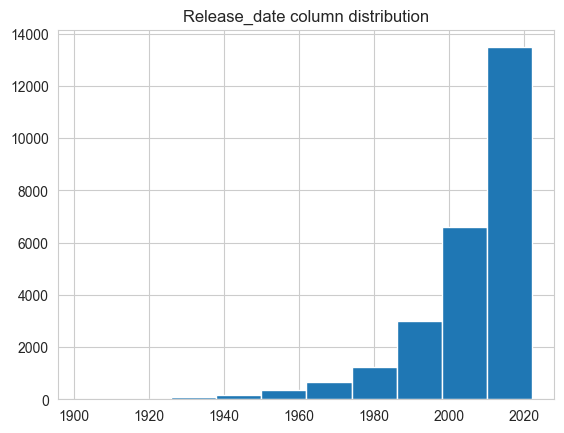

In [48]:
df['Release_Date'].hist()
plt.title('Release_date column distribution')
plt.show()